In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator, FixedFormatter
import csv

from common import make_canvas

import re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Compress width scaling

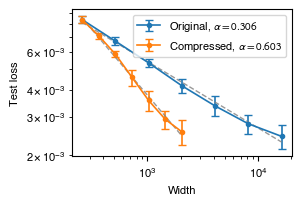

In [7]:
k = 6
train_size = 20000
test_size = 20000
# train_size = 10**4
# test_size = 10**4
train_noise = 0.2
tol = 1e-12
epochs = 2000
batch_size = 128

# AdamW
algo_name = 'AdamW'
lr = 1e-3
task_name = 'harm'


# --- config ---
foldername = f'CPU_{task_name}_{algo_name}_k{k}_trains{train_size}_noise{train_noise}_bs{batch_size}_lr{lr}_epoch{epochs}'

# dstop function as requested
dstop_fn = lambda d: int(16*np.sqrt(d))

# regex to parse filenames like: d{d}_dstop{dstop}_seed{seed}.csv
rx = re.compile(r"d(?P<d>\d+)_dstop(?P<dstop>\d+)_seed(?P<seed>\d+)\.csv$")

# collect per-d lists (aggregate over seeds)
acc = {}  # d -> {"orig": [..], "cp": [..]}
files = glob.glob(os.path.join(foldername, "d*_dstop*_seed*.csv"))

for fp in files:
    m = rx.search(os.path.basename(fp))
    if not m:
        continue
    d = int(m.group("d"))
    # read CSV; take the *last* row (final epoch)
    try:
        df = pd.read_csv(fp)
        last = df.iloc[-1]
        loss_orig = float(last["test_loss_orig"])
        loss_cp   = float(last["test_loss_cp"])
    except Exception as e:
        print(f"Skip {fp}: {e}")
        continue

    if d not in acc:
        acc[d] = {"orig": [], "cp": []}
    acc[d]["orig"].append(loss_orig)
    acc[d]["cp"].append(loss_cp)

# build arrays sorted by d
if not acc:
    raise RuntimeError("No valid files found.")

d_vals = np.array(sorted(acc.keys()), dtype=int)
orig_mean = np.array([np.mean(acc[d]["orig"]) for d in d_vals], dtype=float)
orig_std  = np.array([np.std(acc[d]["orig"], ddof=1) if len(acc[d]["orig"])>1 else 0.0 for d in d_vals], dtype=float)

cp_mean = np.array([np.mean(acc[d]["cp"]) for d in d_vals], dtype=float)
cp_std  = np.array([np.std(acc[d]["cp"], ddof=1) if len(acc[d]["cp"])>1 else 0.0 for d in d_vals], dtype=float)

# x-axis for cp: dstop(d)
dstop_vals = np.array([dstop_fn(d) for d in d_vals], dtype=int)

# fit powerlaw exponent
def fit_powerlaw(x, y):
    """Fit log(y)=a+b log(x); return (a,b) and y_fit on x_sorted."""
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    xs, ys = x[m], y[m]
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    b, a = np.polyfit(np.log(xs), np.log(ys), 1)  # returns slope b, intercept a
    yfit = np.exp(a) * xs**b
    return a, b, xs, yfit

a1, b1, x1, y1_fit = fit_powerlaw(d_vals, orig_mean)
a2, b2, x2, y2_fit = fit_powerlaw(dstop_vals, cp_mean)


# --- plot ---
fig, ax = make_canvas(rows=1, cols=1, axes_width_pt=160, axes_aspect=0.6)

ax.errorbar(d_vals, orig_mean, yerr=orig_std, fmt='-o', ms=3, capsize=3, lw=1.2, label=rf'Original, $\alpha={-b1:.3f}$')
ax.plot(x1, y1_fit, ls='--', lw=1.0, color='gray', alpha=0.8)
ax.errorbar(dstop_vals, cp_mean, yerr=cp_std, fmt='-o', ms=3, capsize=3, lw=1.2, color='tab:orange', label=rf'Compressed, $\alpha={-b2:.3f}$')
ax.plot(x2, y2_fit, ls='--', lw=1.0, color='gray', alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Width")
ax.set_ylabel("Test loss")
# ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig('NSL_width.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

Compress trainds figures

In [9]:
filename = 'trainds_scaling'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

seed = data["seed"].astype(np.int64)
d = data["d"].astype(np.float64)
dstop = data["dstop"].astype(np.float64)
test_loss = data["test_loss_orig"].astype(np.float64)
test_loss_cp = data["test_loss_cp"].astype(np.float64)

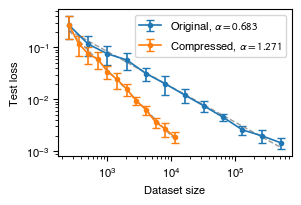

In [10]:
def agg_by(x, y):
    """Aggregate y by unique values of x: return (x_unique, mean, std)."""
    xu, inv = np.unique(x, return_inverse=True)
    means = np.zeros_like(xu, dtype=float)
    stds  = np.zeros_like(xu, dtype=float)
    for i in range(len(xu)):
        yi = y[inv == i]
        means[i] = yi.mean()
        stds[i]  = yi.std(ddof=1) if yi.size > 1 else 0.0
    return xu, means, stds

def fit_powerlaw(x, y):
    """Fit log(y)=a+b log(x); return (a,b) and y_fit on x_sorted."""
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    xs, ys = x[m], y[m]
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    b, a = np.polyfit(np.log(xs), np.log(ys), 1)  # returns slope b, intercept a
    yfit = np.exp(a) * xs**b
    return a, b, xs, yfit

# Aggregate
d_u, tl_mean, tl_std = agg_by(d, test_loss)
ds_u, tlcp_mean, tlcp_std = agg_by(dstop, test_loss_cp)

# fits
a1, b1, x1, y1_fit = fit_powerlaw(d_u, tl_mean)
a2, b2, x2, y2_fit = fit_powerlaw(ds_u, tlcp_mean)

fig, axs = make_canvas(rows=1, cols=1, axes_width_pt=160, axes_aspect=0.6)

# 1) test_loss vs d
axs.errorbar(d_u, tl_mean, yerr=tl_std, fmt='-o', ms=3, capsize=3, lw=1.2, label=rf'Original, $\alpha={-b1:.3f}$')
axs.plot(x1, y1_fit, ls='--', lw=1.0, color='gray', alpha=0.8)
axs.errorbar(ds_u, tlcp_mean, yerr=tlcp_std, fmt='-o', ms=3, capsize=3, lw=1.2, color='tab:orange', label=rf'Compressed, $\alpha={-b2:.3f}$')
axs.plot(x2, y2_fit, ls='--', lw=1.0, color='gray', alpha=0.8)
axs.set_xlabel('Dataset size')
axs.set_ylabel('Test loss')
axs.set_xscale('log')
axs.set_yscale('log')
# axs.grid(True, alpha=0.3)
axs.legend()

plt.tight_layout()
plt.savefig('NSL_dataset.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()